# ⚡ Energy Consumption Forecasting with Darts

This notebook demonstrates a comprehensive time series forecasting project for predicting energy consumption in the PJM East region. We'll compare multiple forecasting models using the Darts library.

## Table of Contents
1. [Setup & Data Ingestion](#1-setup--data-ingestion)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Feature Engineering](#3-feature-engineering)
4. [Model Comparison](#4-model-comparison)
5. [Hyperparameter Tuning](#5-hyperparameter-tuning)
6. [Final Evaluation & Visualization](#6-final-evaluation--visualization)


---
## 1. Setup & Data Ingestion


In [3]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.6 MB/s eta 0:00:00


In [4]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Darts imports
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.utils.statistics import check_seasonality, plot_acf, plot_pacf
from darts.metrics import mape, rmse, mae, smape

# Models
from darts.models import (
    Prophet,
    NBEATSModel,
    RNNModel,
    ExponentialSmoothing,
    NaiveSeasonal
)

# Model selection
from darts.utils.model_selection import train_test_split

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# For reproducibility
np.random.seed(42)

print("All imports successful!")


All imports successful!


### 1.1 Load the Dataset

Download the dataset from [Kaggle](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) and place `PJME_hourly.csv` in the `data/` folder.


In [5]:
# Load the PJME hourly energy consumption data
data_path = 'PJME_hourly.csv'

# Read the CSV file
df = pd.read_csv(data_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(10)


Dataset Shape: (145366, 2)

Columns: ['Datetime', 'PJME_MW']


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
5,2002-12-31 06:00:00,26222.0
6,2002-12-31 07:00:00,28702.0
7,2002-12-31 08:00:00,30698.0
8,2002-12-31 09:00:00,31800.0
9,2002-12-31 10:00:00,32359.0


In [6]:
# Parse datetime and set as index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()

# Rename column for clarity
df = df.rename(columns={'PJME_MW': 'energy_consumption'})

print(f"\nDate Range: {df.index.min()} to {df.index.max()}")
print(f"Total Hours: {len(df):,}")
print(f"Missing Values: {df.isnull().sum().sum()}")

df.head()


Date Range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Total Hours: 145,366
Missing Values: 0


,energy_consumption
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [7]:
# Check for missing timestamps and fill if necessary
date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
missing_dates = date_range.difference(df.index)
df = df[~df.index.duplicated(keep='first')]
print(f"Missing timestamps: {len(missing_dates)}")

if len(missing_dates) > 0:
    print("Filling missing timestamps with interpolation...")
    df = df.reindex(date_range)
    df = df.interpolate(method='time')
    print("Missing values filled!")

# Display statistics
df.describe()


Missing timestamps: 30
Filling missing timestamps with interpolation...
Missing values filled!


,energy_consumption
count,145392.000000
mean,32078.930711
std,6464.279302
min,14544.000000
25%,27571.000000
50%,31420.000000
75%,35647.000000
max,62009.000000


### 1.2 Convert to Darts TimeSeries


In [8]:
# Create Darts TimeSeries object
series = TimeSeries.from_dataframe(
    df.reset_index(),
    time_col='index',
    value_cols='energy_consumption',
    freq='H'
)

print(f"TimeSeries created!")
print(f"Series length: {len(series)}")
print(f"Start: {series.start_time()}")
print(f"End: {series.end_time()}")
print(f"Frequency: {series.freq}")


TimeSeries created!
Series length: 145392
Start: 2002-01-01 01:00:00
End: 2018-08-03 00:00:00
Frequency: <Hour>


---
## 2. Exploratory Data Analysis


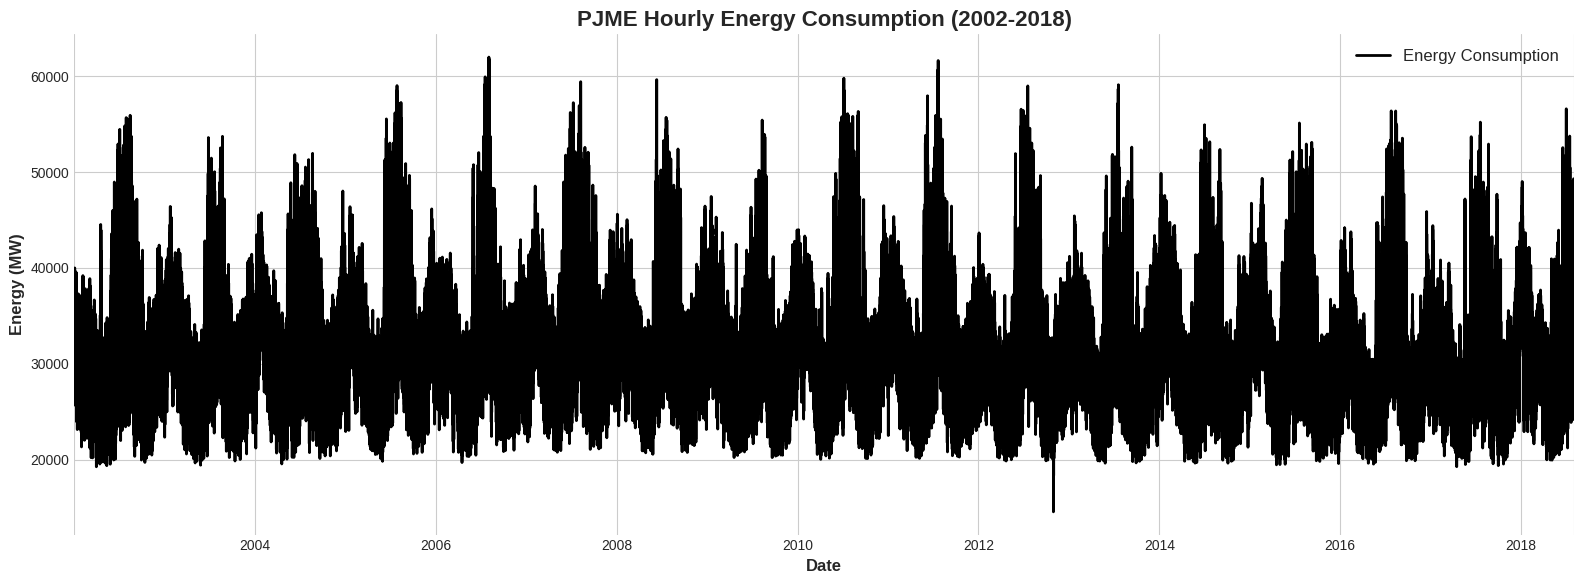

In [9]:
# Plot the full time series
fig, ax = plt.subplots(figsize=(16, 6))

series.plot(ax=ax, label='Energy Consumption')
ax.set_title('PJME Hourly Energy Consumption (2002-2018)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MW)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


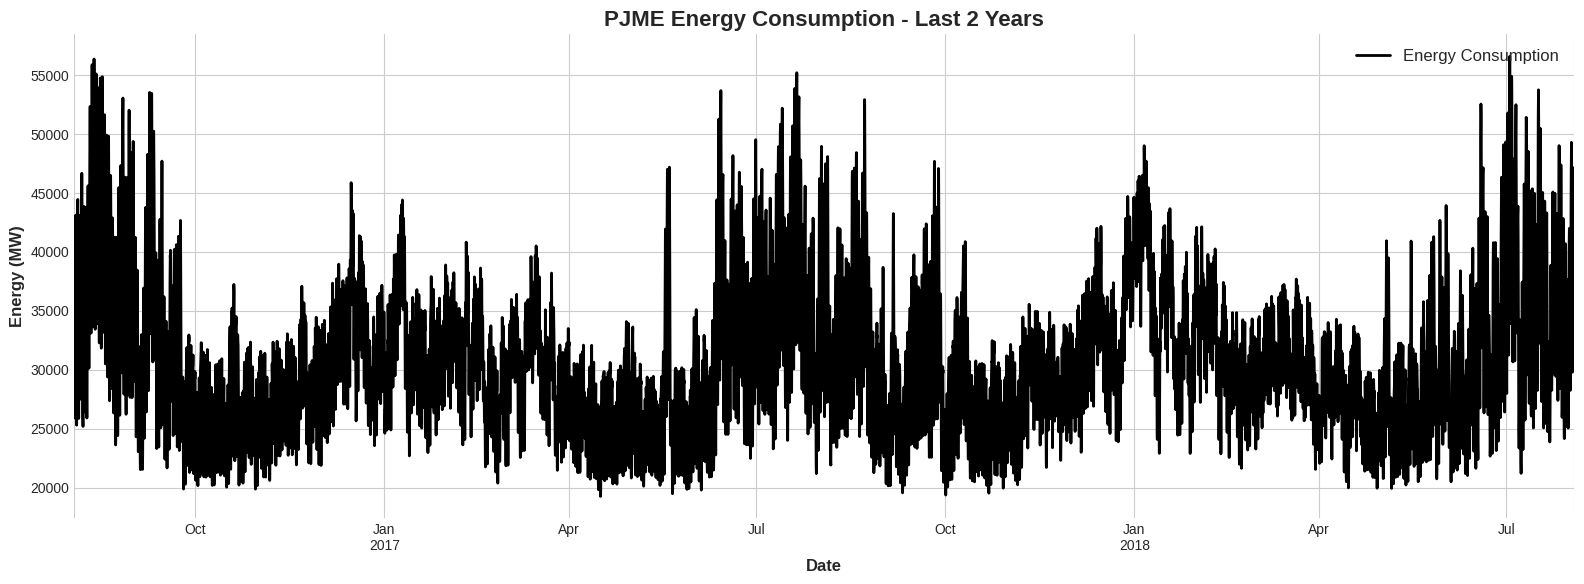

In [10]:
# Zoom into recent data (last 2 years)
recent_series = series[-24*365*2:]  # Last 2 years

fig, ax = plt.subplots(figsize=(16, 6))
recent_series.plot(ax=ax, label='Energy Consumption')
ax.set_title('PJME Energy Consumption - Last 2 Years', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MW)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


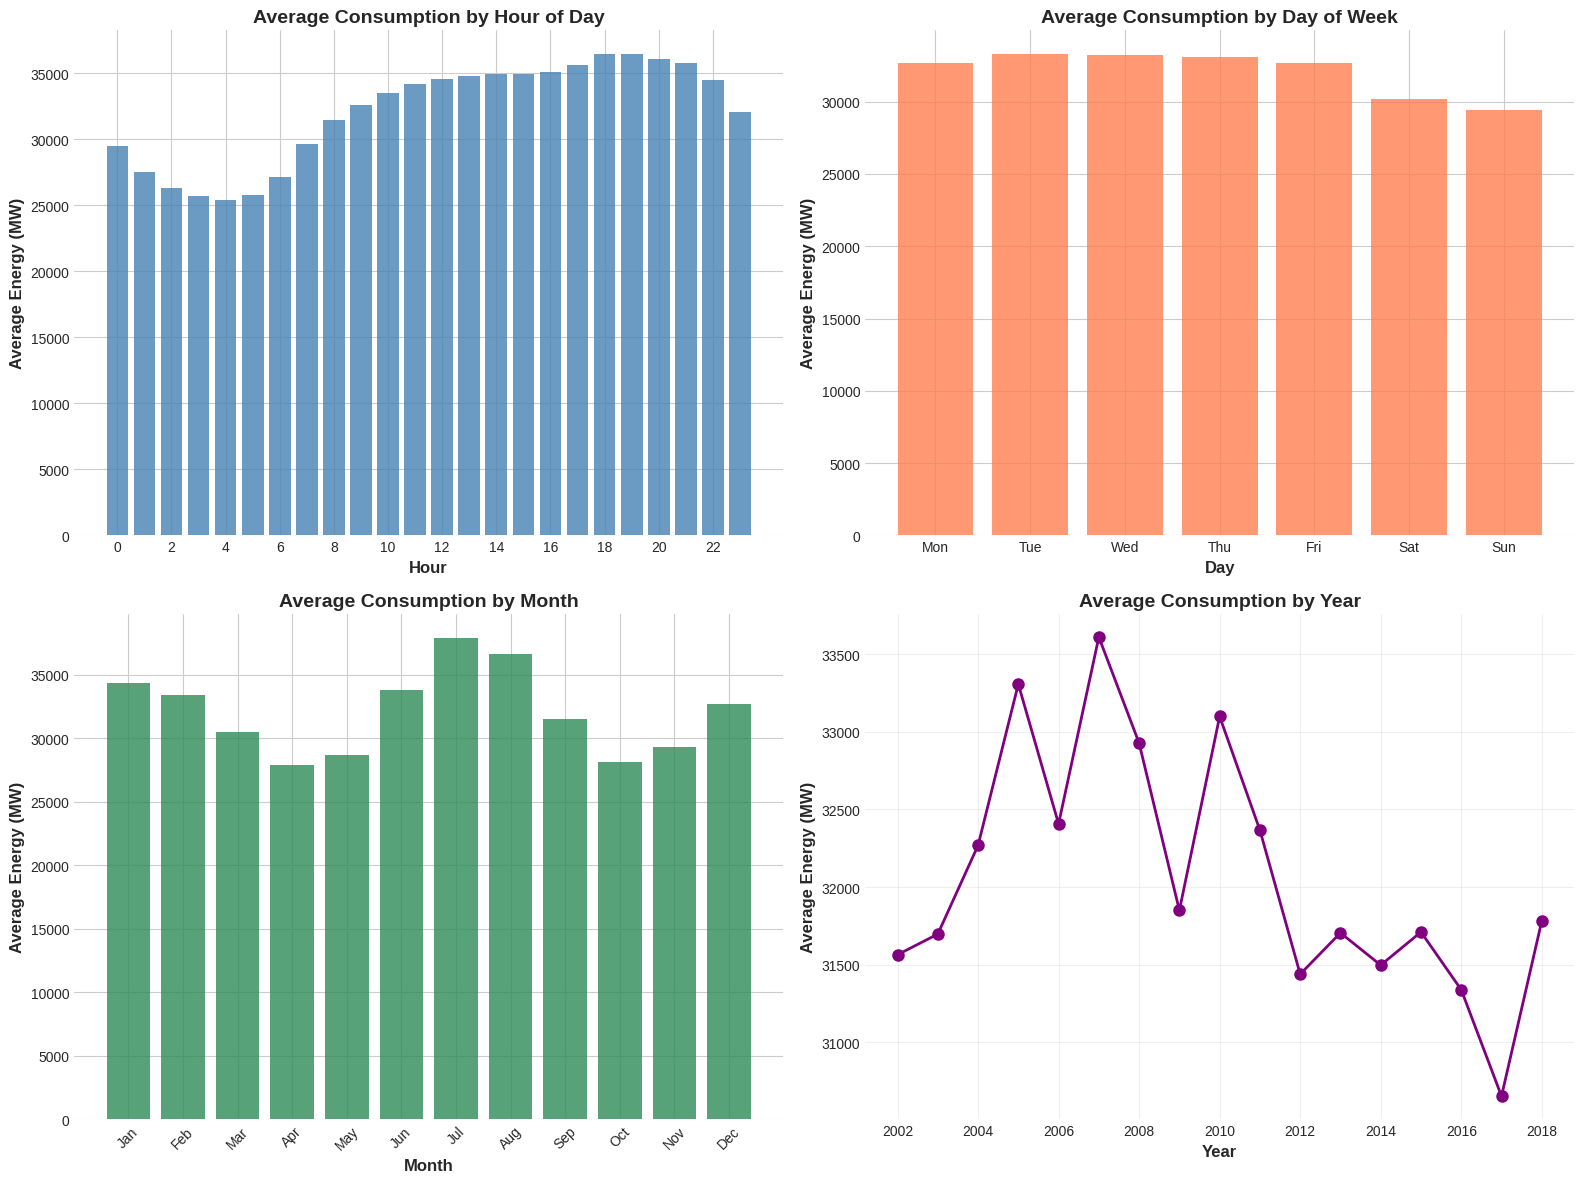

In [11]:
# Analyze seasonality patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Daily pattern (by hour)
hourly_avg = df.groupby(df.index.hour)['energy_consumption'].mean()
axes[0, 0].bar(hourly_avg.index, hourly_avg.values, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Average Consumption by Hour of Day', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Average Energy (MW)')
axes[0, 0].set_xticks(range(0, 24, 2))

# Weekly pattern (by day of week)
daily_avg = df.groupby(df.index.dayofweek)['energy_consumption'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(days, daily_avg.values, color='coral', alpha=0.8)
axes[0, 1].set_title('Average Consumption by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Average Energy (MW)')

# Monthly pattern
monthly_avg = df.groupby(df.index.month)['energy_consumption'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].bar(months, monthly_avg.values, color='seagreen', alpha=0.8)
axes[1, 0].set_title('Average Consumption by Month', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Energy (MW)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Yearly trend
yearly_avg = df.groupby(df.index.year)['energy_consumption'].mean()
axes[1, 1].plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_title('Average Consumption by Year', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Energy (MW)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Check for seasonality using statistical tests
print("Seasonality Analysis:")
print("-"*50)

# Check for daily seasonality (24 hours)
is_seasonal_24, period_24 = check_seasonality(series, m=24, max_lag=48)
print(f"Daily (24h) seasonality: {is_seasonal_24}")

# Check for weekly seasonality (168 hours)
is_seasonal_168, period_168 = check_seasonality(series, m=168, max_lag=336)
print(f"Weekly (168h) seasonality: {is_seasonal_168}")


Seasonality Analysis:
--------------------------------------------------
Daily (24h) seasonality: True
Weekly (168h) seasonality: True


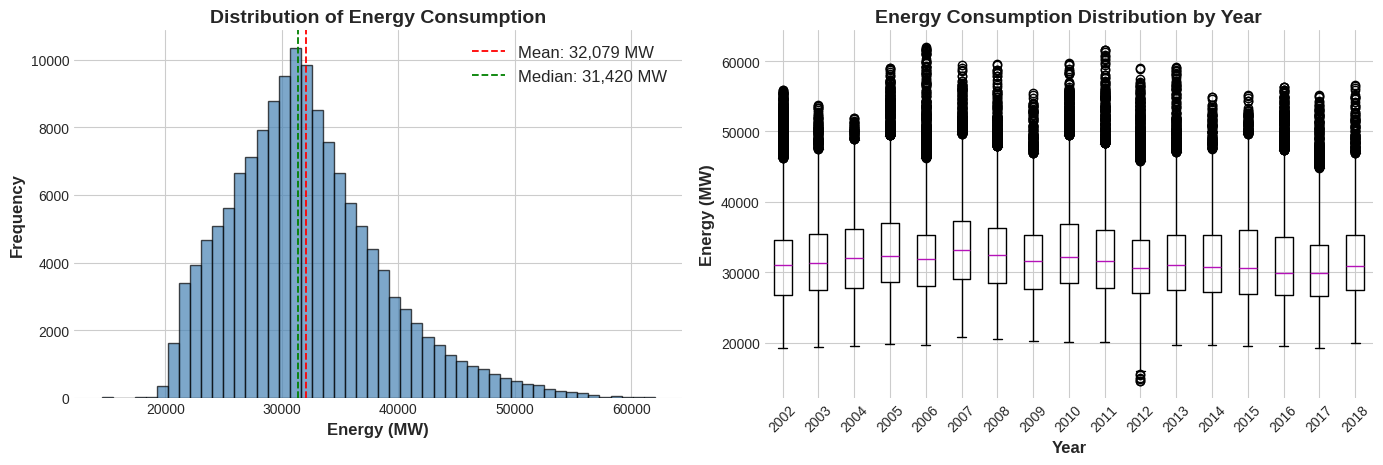

In [13]:
# Distribution of energy consumption
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['energy_consumption'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of Energy Consumption', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Energy (MW)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['energy_consumption'].mean(), color='red', linestyle='--', label=f'Mean: {df["energy_consumption"].mean():,.0f} MW')
axes[0].axvline(df['energy_consumption'].median(), color='green', linestyle='--', label=f'Median: {df["energy_consumption"].median():,.0f} MW')
axes[0].legend()

# Box plot by year
df_yearly = df.copy()
df_yearly['year'] = df_yearly.index.year
df_yearly.boxplot(column='energy_consumption', by='year', ax=axes[1])
axes[1].set_title('Energy Consumption Distribution by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Energy (MW)')
plt.suptitle('')  # Remove automatic title
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---
## 3. Feature Engineering

We'll create additional features to improve model performance:
- **Temporal features**: Hour, day of week, month, quarter
- **Lag features**: Past consumption values
- **Rolling statistics**: Moving averages and standard deviations


---
## 3. Feature Engineering

We'll create additional features to improve model performance:
- **Temporal features**: Hour, day of week, month, quarter
- **Lag features**: Past consumption values
- **Rolling statistics**: Moving averages and standard deviations


In [14]:
def create_features(df):
    """
    Create time-based and statistical features for energy forecasting.
    """
    df = df.copy()

    # Temporal features
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week.astype(int)

    # Is weekend
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

    # Peak hours (typically 7 AM - 10 PM)
    df['is_peak_hour'] = ((df.index.hour >= 7) & (df.index.hour <= 22)).astype(int)

    # Season
    df['season'] = df.index.month.map({
        12: 0, 1: 0, 2: 0,  # Winter
        3: 1, 4: 1, 5: 1,   # Spring
        6: 2, 7: 2, 8: 2,   # Summer
        9: 3, 10: 3, 11: 3  # Fall
    })

    return df

# Apply feature engineering
df_features = create_features(df)
print("Temporal features created!")
df_features.head()


Temporal features created!


,energy_consumption,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,is_weekend,is_peak_hour,season
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1,0,0,0
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1,0,0,0
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1,0,0,0
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1,0,0,0
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1,0,0,0


In [15]:
def add_lag_features(df, target_col='energy_consumption', lags=[1, 2, 3, 24, 48, 168]):
    """
    Add lagged values of the target variable.

    Args:
        df: DataFrame with datetime index
        target_col: Column to create lags for
        lags: List of lag periods (in hours)
    """
    df = df.copy()

    for lag in lags:
        df[f'lag_{lag}h'] = df[target_col].shift(lag)

    return df

def add_rolling_features(df, target_col='energy_consumption', windows=[24, 48, 168]):
    """
    Add rolling statistics features.

    Args:
        df: DataFrame with datetime index
        target_col: Column to compute rolling stats for
        windows: List of window sizes (in hours)
    """
    df = df.copy()

    for window in windows:
        df[f'rolling_mean_{window}h'] = df[target_col].shift(1).rolling(window=window).mean()
        df[f'rolling_std_{window}h'] = df[target_col].shift(1).rolling(window=window).std()
        df[f'rolling_min_{window}h'] = df[target_col].shift(1).rolling(window=window).min()
        df[f'rolling_max_{window}h'] = df[target_col].shift(1).rolling(window=window).max()

    return df

# Add lag features
df_features = add_lag_features(df_features)
print("Lag features created!")

# Add rolling features
df_features = add_rolling_features(df_features)
print("Rolling features created!")

# Display all features
print(f"\nTotal features: {len(df_features.columns)}")
print(f"Columns: {df_features.columns.tolist()}")


Lag features created!
Rolling features created!

Total features: 30
Columns: ['energy_consumption', 'hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear', 'is_weekend', 'is_peak_hour', 'season', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_min_24h', 'rolling_max_24h', 'rolling_mean_48h', 'rolling_std_48h', 'rolling_min_48h', 'rolling_max_48h', 'rolling_mean_168h', 'rolling_std_168h', 'rolling_min_168h', 'rolling_max_168h']


In [16]:
# Create covariates for Darts models
# These are features that can help models understand patterns

# Time-based covariates
covariates_df = df_features[['hour', 'dayofweek', 'month', 'is_weekend', 'is_peak_hour', 'season']].copy()

# Drop rows with NaN (from lag/rolling features)
covariates_df = covariates_df.dropna()

# Create Darts covariates TimeSeries
covariates = TimeSeries.from_dataframe(
    covariates_df.reset_index(),
    time_col='index',
    value_cols=covariates_df.columns.tolist(),
    freq='H'
)

print(f"Covariates TimeSeries created!")
print(f"Covariates shape: {covariates.n_components} features")


Covariates TimeSeries created!
Covariates shape: 6 features


---
## 4. Model Comparison

We'll compare the following models:
1. **Naive Seasonal**: Simple baseline
2. **Exponential Smoothing**: Classical statistical model
3. **Prophet**: Facebook's additive forecasting model
4. **N-BEATS**: Neural Basis Expansion for interpretable time series forecasting
5. **LSTM (RNN)**: Deep learning recurrent neural network


---
## 4. Model Comparison

We'll compare the following models:
1. **Naive Seasonal**: Simple baseline
2. **Exponential Smoothing**: Classical statistical model
3. **Prophet**: Facebook's additive forecasting model
4. **N-BEATS**: Neural Basis Expansion for interpretable time series forecasting
5. **LSTM (RNN)**: Deep learning recurrent neural network


In [17]:
# Train/Test Split
# Use last 30 days for testing (720 hours)
TEST_SIZE = 24 * 30  # 30 days
FORECAST_HORIZON = 24 * 7  # Predict 7 days ahead (168 hours)

# For faster training, we'll use last 3 years of data
series_subset = series[-24*365*3:]  # Last 3 years

train, test = series_subset[:-TEST_SIZE], series_subset[-TEST_SIZE:]

print(f"Training set: {len(train)} hours ({len(train)/24:.0f} days)")
print(f"Test set: {len(test)} hours ({len(test)/24:.0f} days)")
print(f"Forecast horizon: {FORECAST_HORIZON} hours ({FORECAST_HORIZON/24:.0f} days)")


Training set: 25560 hours (1065 days)
Test set: 720 hours (30 days)
Forecast horizon: 168 hours (7 days)


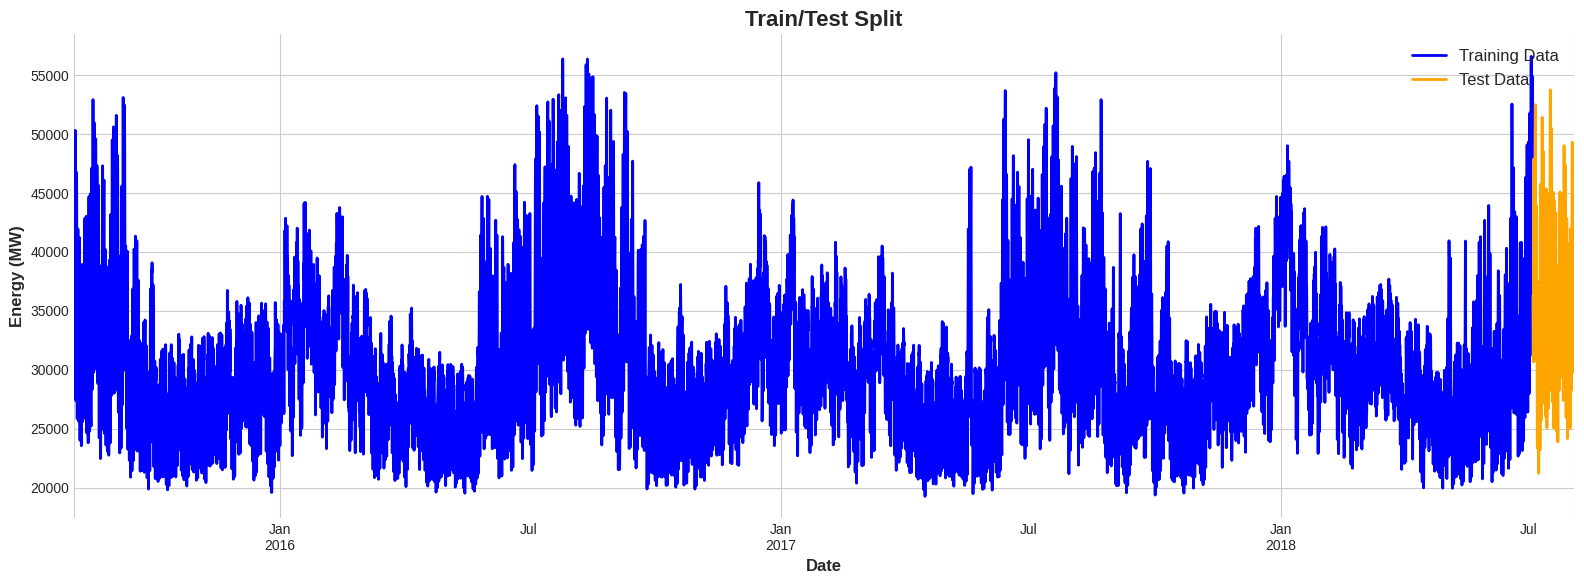

In [18]:
# Visualize train/test split
fig, ax = plt.subplots(figsize=(16, 6))

train.plot(ax=ax, label='Training Data', color='blue')
test.plot(ax=ax, label='Test Data', color='orange')

ax.set_title('Train/Test Split', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MW)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


In [19]:
# Scale the data for neural network models
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

print("Data scaled for neural network models!")


Data scaled for neural network models!


In [20]:
# Dictionary to store model results
model_results = {}

def evaluate_model(model_name, predictions, actual):
    """
    Evaluate model performance using multiple metrics.
    """
    # Ensure predictions match the actual length
    pred_values = predictions[:len(actual)]

    results = {
        'MAPE': mape(actual, pred_values),
        'RMSE': rmse(actual, pred_values),
        'MAE': mae(actual, pred_values),
        'SMAPE': smape(actual, pred_values)
    }

    print(f"\n{model_name} Results:")
    print(f"   MAPE:  {results['MAPE']:.2f}%")
    print(f"   RMSE:  {results['RMSE']:,.2f} MW")
    print(f"   MAE:   {results['MAE']:,.2f} MW")
    print(f"   SMAPE: {results['SMAPE']:.2f}%")

    return results


### 4.1 Baseline: Naive Seasonal Model


In [21]:
print("Training Naive Seasonal Model...")

# Naive seasonal with weekly seasonality (168 hours)
naive_model = NaiveSeasonal(K=168)  # Weekly seasonality
naive_model.fit(train)

# Predict
naive_pred = naive_model.predict(len(test))

# Evaluate
model_results['Naive Seasonal'] = evaluate_model('Naive Seasonal', naive_pred, test)
model_results['Naive Seasonal']['predictions'] = naive_pred

print("Naive Seasonal Model trained!")


Training Naive Seasonal Model...

Naive Seasonal Results:
   MAPE:  17.59%
   RMSE:  7,516.51 MW
   MAE:   6,193.28 MW
   SMAPE: 16.29%
Naive Seasonal Model trained!


### 4.2 Exponential Smoothing


In [22]:
print("Training Exponential Smoothing Model...")
from darts.utils.utils import ModelMode

# Exponential Smoothing with seasonality
exp_model = ExponentialSmoothing(
    seasonal_periods=24,  # Daily seasonality
    trend=None,
    seasonal=ModelMode.ADDITIVE
)
exp_model.fit(train)

# Predict
exp_pred = exp_model.predict(len(test))

# Evaluate
model_results['Exponential Smoothing'] = evaluate_model('Exponential Smoothing', exp_pred, test)
model_results['Exponential Smoothing']['predictions'] = exp_pred

print("Exponential Smoothing Model trained!")


Training Exponential Smoothing Model...

Exponential Smoothing Results:
   MAPE:  23.32%
   RMSE:  8,720.33 MW
   MAE:   7,628.05 MW
   SMAPE: 20.06%
Exponential Smoothing Model trained!


### 4.3 Prophet Model


In [23]:
print("Training Prophet Model...")
print("   (This may take a few minutes...)")

# Prophet model with custom seasonality
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    seasonality_mode='multiplicative'
)

prophet_model.fit(train)

# Predict
prophet_pred = prophet_model.predict(len(test))

# Evaluate
model_results['Prophet'] = evaluate_model('Prophet', prophet_pred, test)
model_results['Prophet']['predictions'] = prophet_pred

print("Prophet Model trained!")


Training Prophet Model...
   (This may take a few minutes...)

Prophet Results:
   MAPE:  9.87%
   RMSE:  4,082.21 MW
   MAE:   3,291.30 MW
   SMAPE: 9.32%
Prophet Model trained!


### 4.4 N-BEATS Model (Deep Learning)


In [24]:
import torch

print("Training N-BEATS Model...")
print("   (This may take several minutes...)")

# Optimization for A100 GPU
torch.set_float32_matmul_precision('medium')

# N-BEATS model
nbeats_model = NBEATSModel(
    input_chunk_length=168,  # 1 week of history
    output_chunk_length=24,   # Predict 24 hours ahead
    generic_architecture=True,
    num_stacks=10,
    num_blocks=1,
    num_layers=4,
    layer_widths=256,
    n_epochs=50,
    batch_size=1024,
    random_state=42,
    pl_trainer_kwargs={
        "enable_progress_bar": True,
        "accelerator": "gpu",
        "precision": "16-mixed"  # Enable mixed precision
    }
)

# Train on scaled data
train_scaled = train_scaled.astype(np.float32)
nbeats_model.fit(train_scaled, verbose=True)

# Predict and inverse transform
nbeats_pred_scaled = nbeats_model.predict(len(test))
nbeats_pred = scaler.inverse_transform(nbeats_pred_scaled)

# Evaluate
model_results['N-BEATS'] = evaluate_model('N-BEATS', nbeats_pred, test)
model_results['N-BEATS']['predictions'] = nbeats_pred

print("N-BEATS Model trained!")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training N-BEATS Model...
   (This may take several minutes...)


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 2.4 M  | train
-------------------------------------------------------------
2.4 M     Trainable params
2.3 K     Non-trainable params
2.4 M     Total params
9.774     Total estimated model params size (MB)
136       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


N-BEATS Results:
   MAPE:  10.12%
   RMSE:  4,725.78 MW
   MAE:   3,747.74 MW
   SMAPE: 10.55%
N-BEATS Model trained!


### 4.5 LSTM Model (Deep Learning)


In [25]:
print("Training LSTM Model...")
print("   (This may take several minutes...)")

# LSTM model using Darts RNNModel
lstm_model = RNNModel(
    model='LSTM',
    input_chunk_length=168,  # 1 week of history
    output_chunk_length=24,   # Predict 24 hours ahead
    training_length=192,      # 168 + 24, needed to cover input + output
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.1,
    batch_size=1024,  # Increased for A100
    n_epochs=50,
    random_state=42,
    pl_trainer_kwargs={
        "enable_progress_bar": True,
        "accelerator": "gpu",
        "precision": "16-mixed"  # Enable mixed precision
    }
)

# Train on scaled data
lstm_model.fit(train_scaled, verbose=True)

# Predict and inverse transform
lstm_pred_scaled = lstm_model.predict(len(test))
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

# Evaluate
model_results['LSTM'] = evaluate_model('LSTM', lstm_pred, test)
model_results['LSTM']['predictions'] = lstm_pred

print("LSTM Model trained!")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 50.4 K | train
6 | V               | Linear           | 65     | train
---------------------------

Training LSTM Model...
   (This may take several minutes...)


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


LSTM Results:
   MAPE:  15.20%
   RMSE:  6,303.05 MW
   MAE:   5,042.33 MW
   SMAPE: 14.10%
LSTM Model trained!


In [26]:
# Summary comparison of all models
print("\n" + "-"*60)
print("MODEL COMPARISON SUMMARY")
print("-"*60)

# Create summary dataframe
summary_data = []
for model_name, results in model_results.items():
    summary_data.append({
        'Model': model_name,
        'MAPE (%)': results['MAPE'],
        'RMSE (MW)': results['RMSE'],
        'MAE (MW)': results['MAE'],
        'SMAPE (%)': results['SMAPE']
    })

summary_df = pd.DataFrame(summary_data)
# Correcting the column name for sorting
summary_df = summary_df.sort_values('MAPE (%)')
summary_df = summary_df.reset_index(drop=True)

# Format the display
summary_df['MAPE (%)'] = summary_df['MAPE (%)'].round(2)
summary_df['RMSE (MW)'] = summary_df['RMSE (MW)'].round(0).astype(int)
summary_df['MAE (MW)'] = summary_df['MAE (MW)'].round(0).astype(int)
summary_df['SMAPE (%)'] = summary_df['SMAPE (%)'].round(2)

print(summary_df.to_string(index=False))

best_model = summary_df.iloc[0]['Model']
print(f"\nBest Model: {best_model}")


------------------------------------------------------------
MODEL COMPARISON SUMMARY
------------------------------------------------------------
                Model  MAPE (%)  RMSE (MW)  MAE (MW)  SMAPE (%)
              Prophet      9.87       4082      3291       9.32
              N-BEATS     10.12       4726      3748      10.55
                 LSTM     15.20       6303      5042      14.10
       Naive Seasonal     17.59       7517      6193      16.29
Exponential Smoothing     23.32       8720      7628      20.06

Best Model: Prophet


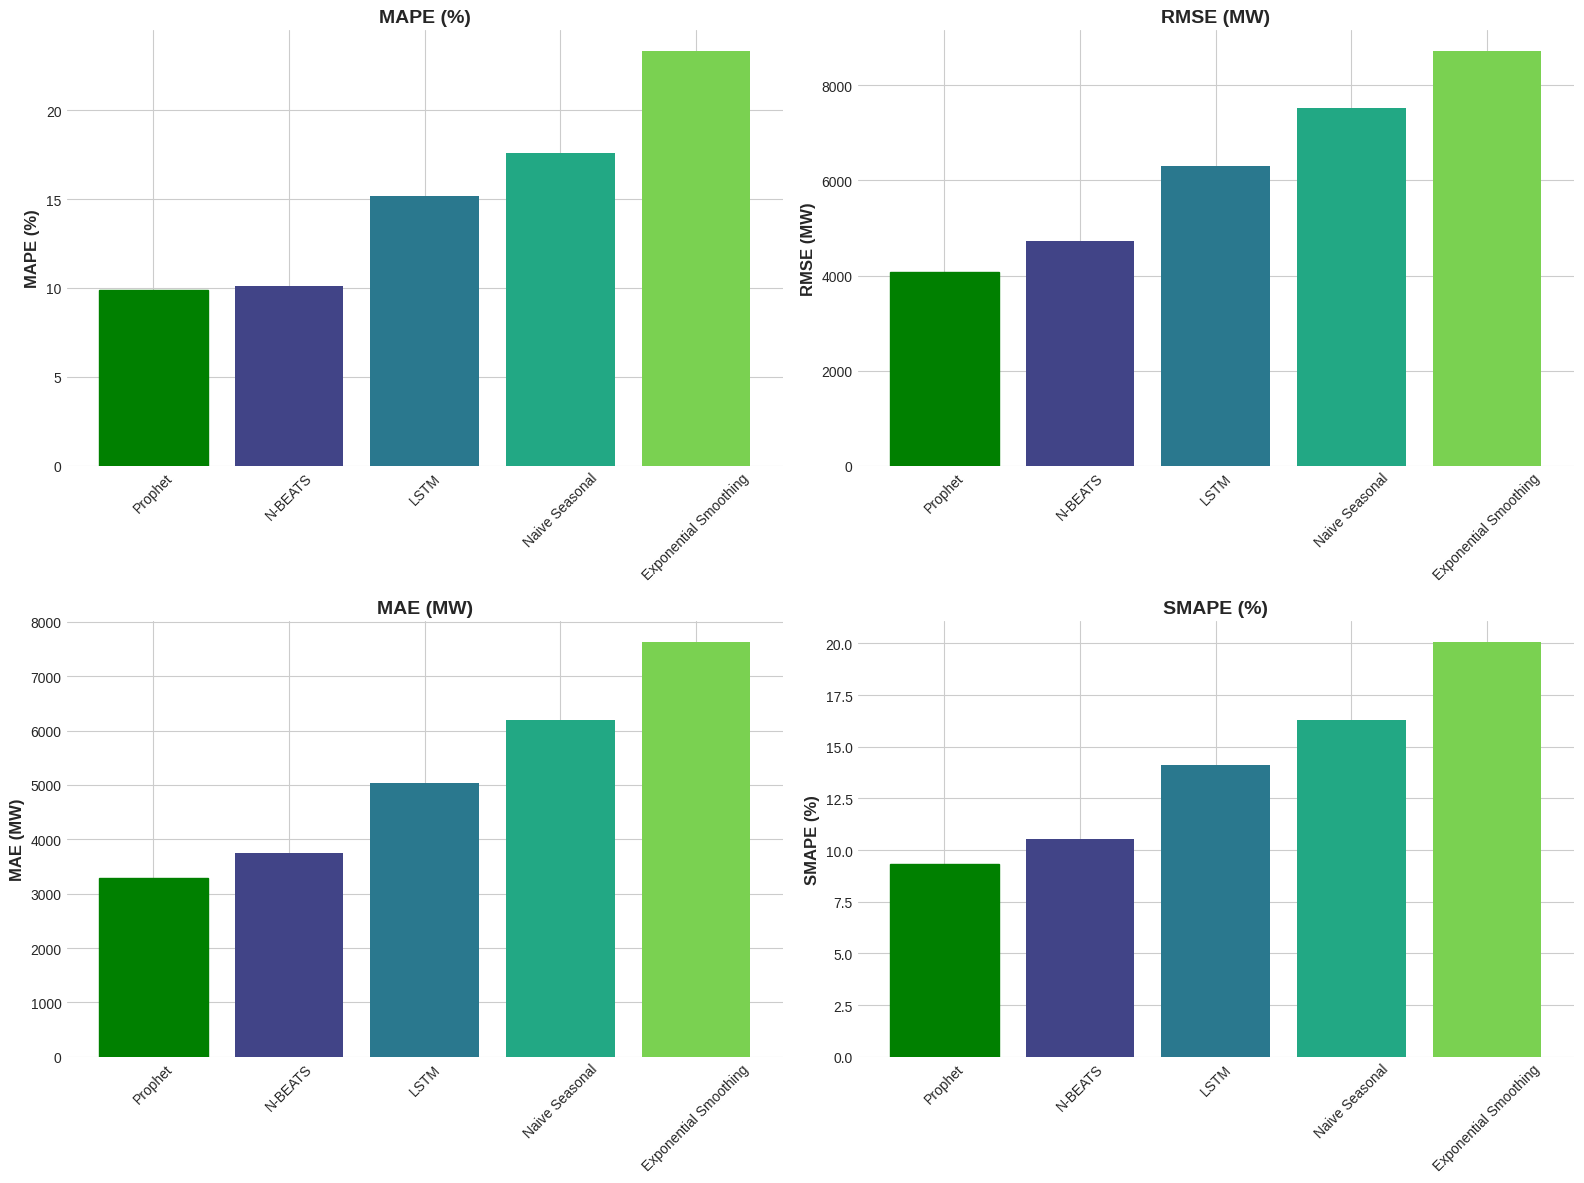

In [27]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['MAPE (%)', 'RMSE (MW)', 'MAE (MW)', 'SMAPE (%)']
colors = plt.cm.viridis(np.linspace(0, 0.8, len(summary_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(summary_df['Model'], summary_df[metric], color=colors)
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

    # Highlight the best
    best_idx = summary_df[metric].idxmin()
    bars[best_idx].set_color('green')
    bars[best_idx].set_alpha(1.0)

plt.tight_layout()
plt.show()


---
## 5. Hyperparameter Tuning

Let's perform hyperparameter optimization for the best performing model.


In [28]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm

# We'll tune N-BEATS (or the best model) using grid search
print("Hyperparameter Tuning for N-BEATS")
print("-"*50)

# Define parameter grid for N-BEATS
param_grid = {
    'input_chunk_length': [72, 168],  # 3 days or 1 week
    'output_chunk_length': [24, 48],  # 1 day or 2 days
    'num_stacks': [5, 10],
    'num_layers': [2, 4],
    'layer_widths': [128, 256]
}

# For faster tuning, use a smaller validation set
VAL_SIZE = 24 * 7  # 1 week
train_tune = train_scaled[:-VAL_SIZE]
val_tune = train_scaled[-VAL_SIZE:]

print(f"Tuning train size: {len(train_tune)} hours")
print(f"Validation size: {len(val_tune)} hours")
print(f"Total parameter combinations: {len(list(ParameterGrid(param_grid)))}")


Hyperparameter Tuning for N-BEATS
--------------------------------------------------
Tuning train size: 25392 hours
Validation size: 168 hours
Total parameter combinations: 32


In [29]:
# Grid search (simplified for demonstration)
# In practice, you might want to use more epochs and a larger grid

tuning_results = []

# Use a subset of the grid for faster execution
reduced_grid = {
    'input_chunk_length': [168],
    'output_chunk_length': [24],
    'num_stacks': [5, 10],
    'num_layers': [2, 4],
    'layer_widths': [128, 256]
}

print("Running Grid Search on A100...")
print("   (This may take a while...)\n")

# Optimization for A100
import torch
torch.set_float32_matmul_precision('medium')

for params in tqdm(list(ParameterGrid(reduced_grid))):
    try:
        model = NBEATSModel(
            input_chunk_length=params['input_chunk_length'],
            output_chunk_length=params['output_chunk_length'],
            generic_architecture=True,
            num_stacks=params['num_stacks'],
            num_blocks=1,
            num_layers=params['num_layers'],
            layer_widths=params['layer_widths'],
            n_epochs=20,  # Reduced for faster tuning
            batch_size=1024, # Optimized for A100
            random_state=42,
            pl_trainer_kwargs={
                "enable_progress_bar": False,
                "accelerator": "gpu",
                "precision": "16-mixed" # Mixed precision
            }
        )

        model.fit(train_tune, verbose=False)
        pred = model.predict(len(val_tune))

        score = mape(val_tune, pred)
        params['mape'] = score
        tuning_results.append(params)

        print(f"   Params: {params} -> MAPE: {score:.2f}%")

    except Exception as e:
        print(f"   Error with params {params}: {e}")
        continue

print("\nGrid Search Complete!")

Running Grid Search on A100...
   (This may take a while...)



  0%|          | 0/8 [00:00<?, ?it/s]WARNING:darts.models.forecasting.torch_forecasting_model:Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_light

   Params: {'input_chunk_length': 168, 'layer_widths': 128, 'num_layers': 2, 'num_stacks': 5, 'output_chunk_length': 24, 'mape': np.float32(23.490805)} -> MAPE: 23.49%


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 25%|██▌       | 2/8 [00:28<01:28, 14.78s/it]WARNING:darts.models.forecasting.torch_forecasting_model:Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytor

   Params: {'input_chunk_length': 168, 'layer_widths': 128, 'num_layers': 2, 'num_stacks': 10, 'output_chunk_length': 24, 'mape': np.float32(38.3215)} -> MAPE: 38.32%


...

   Params: {'input_chunk_length': 168, 'layer_widths': 256, 'num_layers': 2, 'num_stacks': 10, 'output_chunk_length': 24, 'mape': np.float32(31.040434)} -> MAPE: 31.04%


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
 88%|████████▊ | 7/8 [01:44<00:14, 14.98s/it]WARNING:darts.models.forecasting.torch_forecasting_model:Detected user-defined float16-like precision. For mixed precision training, recommended options are 'bf16-mixed' and '16-mixed'.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytor

   Params: {'input_chunk_length': 168, 'layer_widths': 256, 'num_layers': 4, 'num_stacks': 5, 'output_chunk_length': 24, 'mape': np.float32(23.898449)} -> MAPE: 23.90%


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
100%|██████████| 8/8 [02:05<00:00, 15.64s/it]

   Params: {'input_chunk_length': 168, 'layer_widths': 256, 'num_layers': 4, 'num_stacks': 10, 'output_chunk_length': 24, 'mape': np.float32(48.660095)} -> MAPE: 48.66%

Grid Search Complete!


In [30]:
# Find best parameters
tuning_df = pd.DataFrame(tuning_results)
tuning_df = tuning_df.sort_values('mape')

print("Hyperparameter Tuning Results:")
print("="*60)
print(tuning_df.to_string(index=False))

best_params = tuning_df.iloc[0].to_dict()
del best_params['mape']

print(f"\nBest Parameters:")
for key, value in best_params.items():
    print(f"   {key}: {value}")


Hyperparameter Tuning Results:
 input_chunk_length  layer_widths  num_layers  num_stacks  output_chunk_length      mape
                168           128           2           5                   24 23.490805
                168           256           4           5                   24 23.898449
                168           256           2          10                   24 31.040434
                168           256           2           5                   24 34.711372
                168           128           4           5                   24 35.568714
                168           128           2          10                   24 38.321499
                168           128           4          10                   24 47.374825
                168           256           4          10                   24 48.660095

Best Parameters:
   input_chunk_length: 168.0
   layer_widths: 128.0
   num_layers: 2.0
   num_stacks: 5.0
   output_chunk_length: 24.0


In [31]:
# Train final optimized model
print("\nTraining Optimized N-BEATS Model...")

# Ensure A100 optimization is applied here too
import torch
torch.set_float32_matmul_precision('medium')

optimized_nbeats = NBEATSModel(
    input_chunk_length=int(best_params['input_chunk_length']),
    output_chunk_length=int(best_params['output_chunk_length']),
    generic_architecture=True,
    num_stacks=int(best_params['num_stacks']),
    num_blocks=1,
    num_layers=int(best_params['num_layers']),
    layer_widths=int(best_params['layer_widths']),
    n_epochs=200,  # More epochs for final model
    batch_size=1024, # Optimized for A100
    random_state=42,
    pl_trainer_kwargs={
        "enable_progress_bar": True,
        "accelerator": "gpu",
        "precision": "16-mixed" # Enable mixed precision
    }
)

optimized_nbeats.fit(train_scaled, verbose=True)

# Predict and evaluate
optimized_pred_scaled = optimized_nbeats.predict(len(test))
optimized_pred = scaler.inverse_transform(optimized_pred_scaled)

model_results['Optimized N-BEATS'] = evaluate_model('Optimized N-BEATS', optimized_pred, test)
model_results['Optimized N-BEATS']['predictions'] = optimized_pred

print("\nOptimized N-BEATS Model trained!")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 202 K  | train
-------------------------------------------------------------
201 K     Trainable p


Training Optimized N-BEATS Model...


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


Optimized N-BEATS Results:
   MAPE:  8.54%
   RMSE:  3,638.71 MW
   MAE:   2,921.18 MW
   SMAPE: 8.28%

Optimized N-BEATS Model trained!


### 5.1 Cross-Validation


In [32]:
# Time series cross-validation using expanding window
print("Running Time Series Cross-Validation...")

# Use a smaller series for CV to save time
cv_series = series_subset[-24*365:]  # Last year
cv_train = scaler.fit_transform(cv_series[:-TEST_SIZE])
cv_test = scaler.transform(cv_series[-TEST_SIZE:])

# Create a simpler model for cross-validation
cv_model = NBEATSModel(
    input_chunk_length=168,
    output_chunk_length=24,
    generic_architecture=True,
    num_stacks=5,
    num_blocks=1,
    num_layers=2,
    layer_widths=128,
    n_epochs=30,
    random_state=42,
    pl_trainer_kwargs={
        "enable_progress_bar": False,
        "accelerator": "auto",
    }
)

print("\nPerforming backtesting...")


Running Time Series Cross-Validation...

Performing backtesting...


In [33]:
# Historical forecasts (backtesting)
cv_model.fit(cv_train)

historical_forecasts = cv_model.historical_forecasts(
    series=cv_series[-TEST_SIZE-168*4:],  # Include some training data
    start=cv_series.time_index[-TEST_SIZE],  # Start predictions from test start
    forecast_horizon=24,
    stride=24 * 7,  # Evaluate weekly
    retrain=False,
    verbose=True
)

print(f"\nGenerated {len(historical_forecasts)} forecast windows")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 202 K  | train
-------------------------------------------------------------
201 K     Trainable params
1.7 K     Non-trainable params
202 K     Total params
0.812     Total estimated m

Predicting: |          | 0/? [00:00<?, ?it/s]


Generated 5 forecast windows


In [34]:
# Evaluate CV performance
cv_scores = []

for i, forecast in enumerate(historical_forecasts):
    # Get corresponding actual values
    actual = cv_series.slice_intersect(forecast)
    if len(actual) > 0:
        score = mape(actual, forecast)
        cv_scores.append(score)

if cv_scores:
    print(f"\nCross-Validation Results:")
    print(f"   Mean MAPE: {np.mean(cv_scores):.2f}%")
    print(f"   Std MAPE:  {np.std(cv_scores):.2f}%")
    print(f"   Min MAPE:  {np.min(cv_scores):.2f}%")
    print(f"   Max MAPE:  {np.max(cv_scores):.2f}%")


ERROR:darts.timeseries:IndexError: Integer index out of range.



Cross-Validation Results:
   Mean MAPE: 35.45%
   Std MAPE:  15.76%
   Min MAPE:  17.14%
   Max MAPE:  54.18%


---
## 6. Final Evaluation & Visualization


In [38]:
# Final summary comparison
print("\n" + "-"*70)
print("FINAL MODEL COMPARISON")
print("-"*70)

# Create final summary
final_summary = []
for model_name, results in model_results.items():
    final_summary.append({
        'Model': model_name,
        'MAPE (%)': round(results['MAPE'], 2),
        'RMSE (MW)': int(round(results['RMSE'])),
        'MAE (MW)': int(round(results['MAE'])),
        'SMAPE (%)': round(results['SMAPE'], 2)
    })

final_df = pd.DataFrame(final_summary).sort_values('MAPE (%)')
final_df = final_df.reset_index(drop=True)

print(final_df.to_string(index=False))

best_model_name = final_df.iloc[0]['Model']
print(f"\nBEST MODEL: {best_model_name}")
print(f"   MAPE: {final_df.iloc[0]['MAPE (%)']}%)")



----------------------------------------------------------------------
FINAL MODEL COMPARISON
----------------------------------------------------------------------
                Model  MAPE (%)  RMSE (MW)  MAE (MW)  SMAPE (%)
    Optimized N-BEATS      8.54       3639      2921       8.28
              Prophet      9.87       4082      3291       9.32
              N-BEATS     10.12       4726      3748      10.55
                 LSTM     15.20       6303      5042      14.10
       Naive Seasonal     17.59       7517      6193      16.29
Exponential Smoothing     23.32       8720      7628      20.06

BEST MODEL: Optimized N-BEATS
   MAPE: 8.54%)


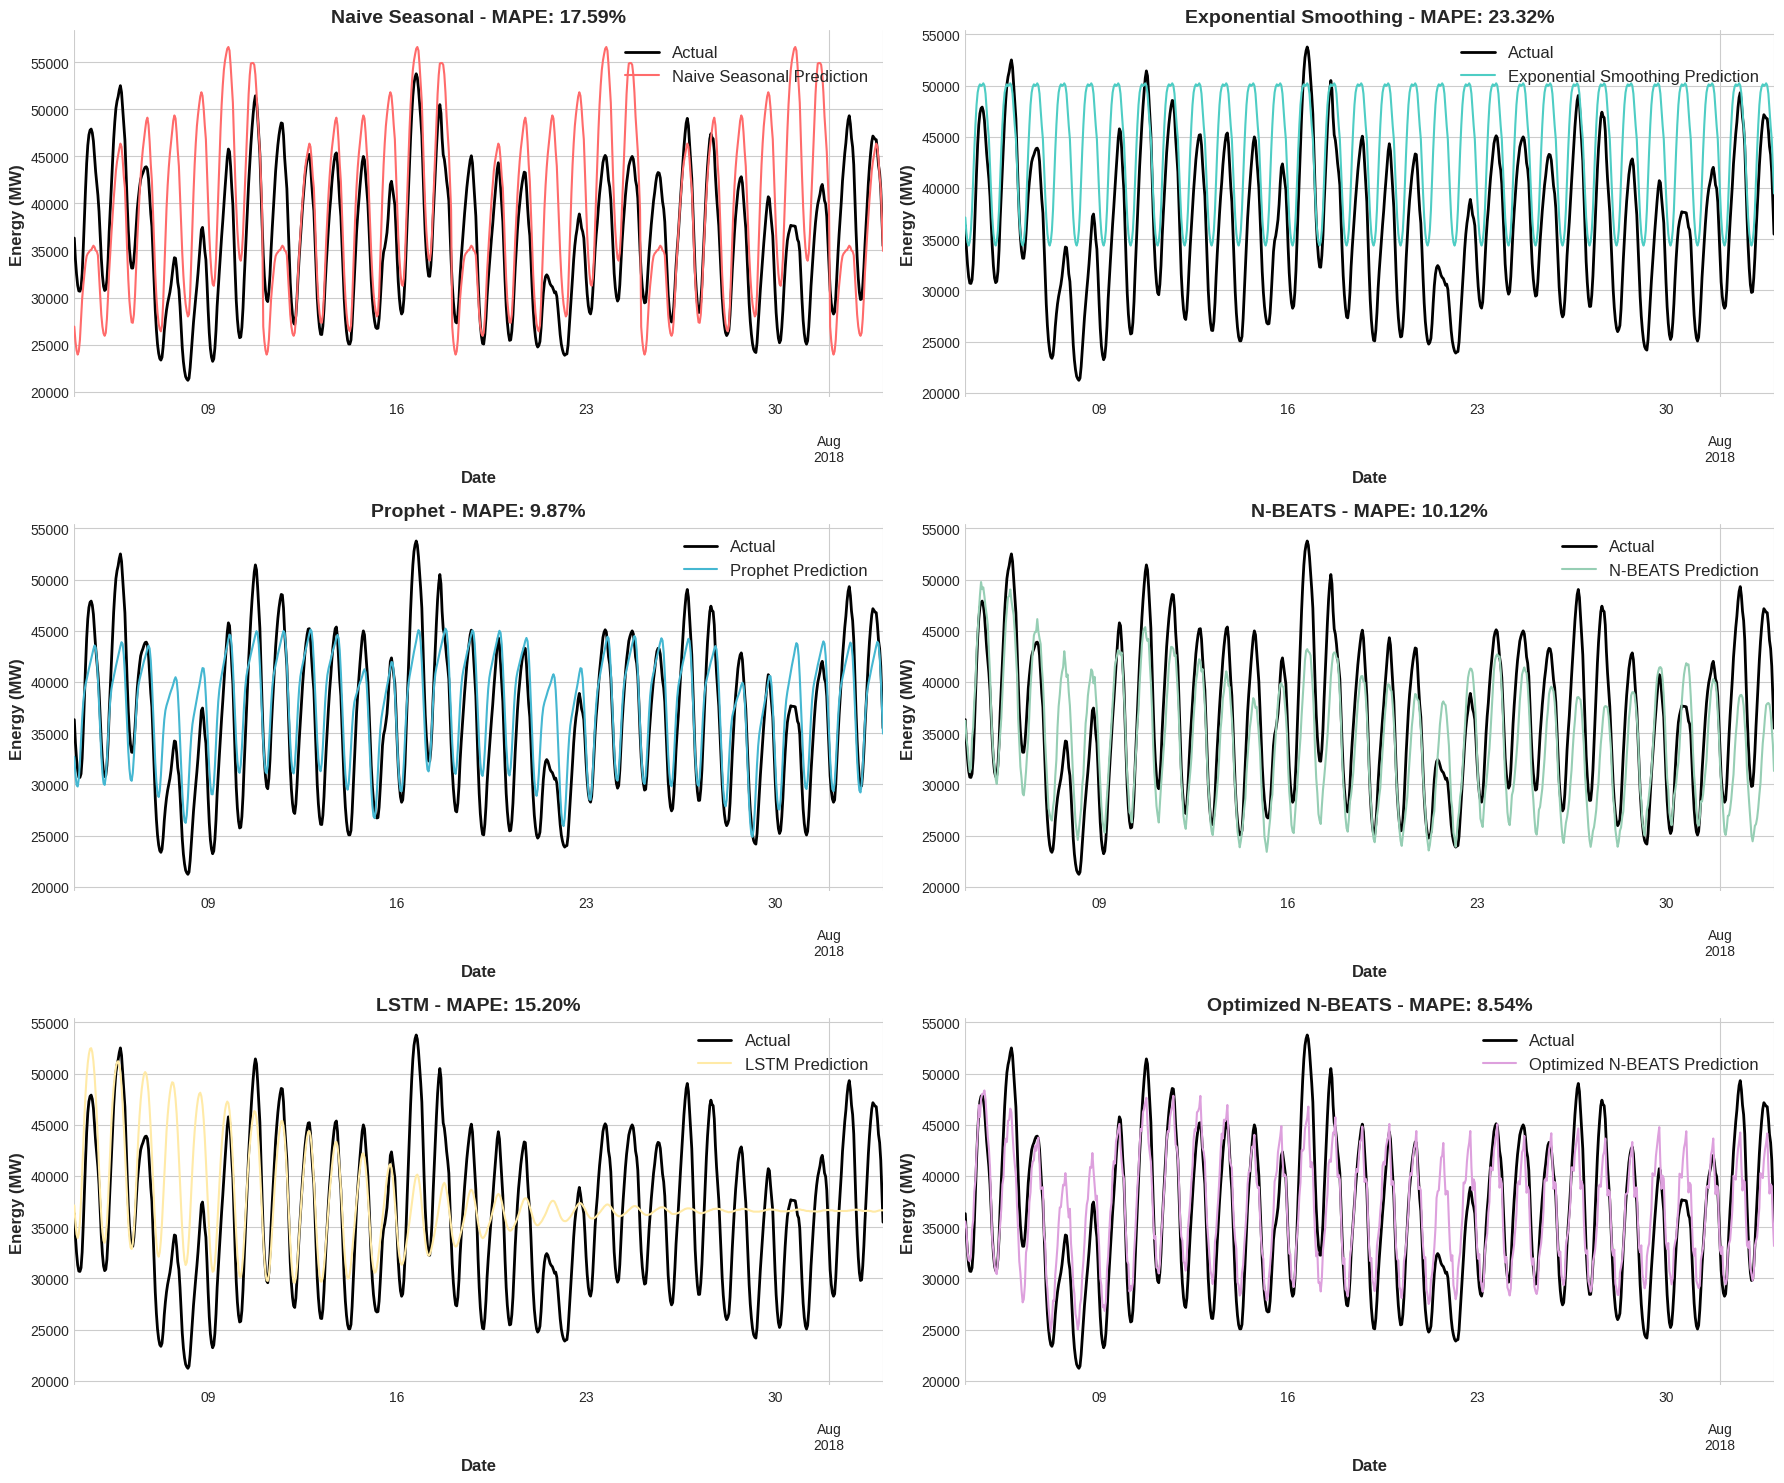


Saved: model_comparison.png


In [39]:
# Plot all predictions vs actual
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

colors = {
    'Naive Seasonal': '#FF6B6B',
    'Exponential Smoothing': '#4ECDC4',
    'Prophet': '#45B7D1',
    'N-BEATS': '#96CEB4',
    'LSTM': '#FFEAA7',
    'Optimized N-BEATS': '#DDA0DD'
}

for idx, (model_name, results) in enumerate(model_results.items()):
    if idx >= len(axes):
        break
    ax = axes[idx]

    # Plot actual
    test.plot(ax=ax, label='Actual', color='black', linewidth=2)

    # Plot prediction
    pred = results['predictions']
    pred.plot(ax=ax, label=f'{model_name} Prediction', color=colors.get(model_name, 'blue'), linewidth=1.5)

    ax.set_title(f'{model_name} - MAPE: {results["MAPE"]:.2f}%', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Energy (MW)')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: model_comparison.png")


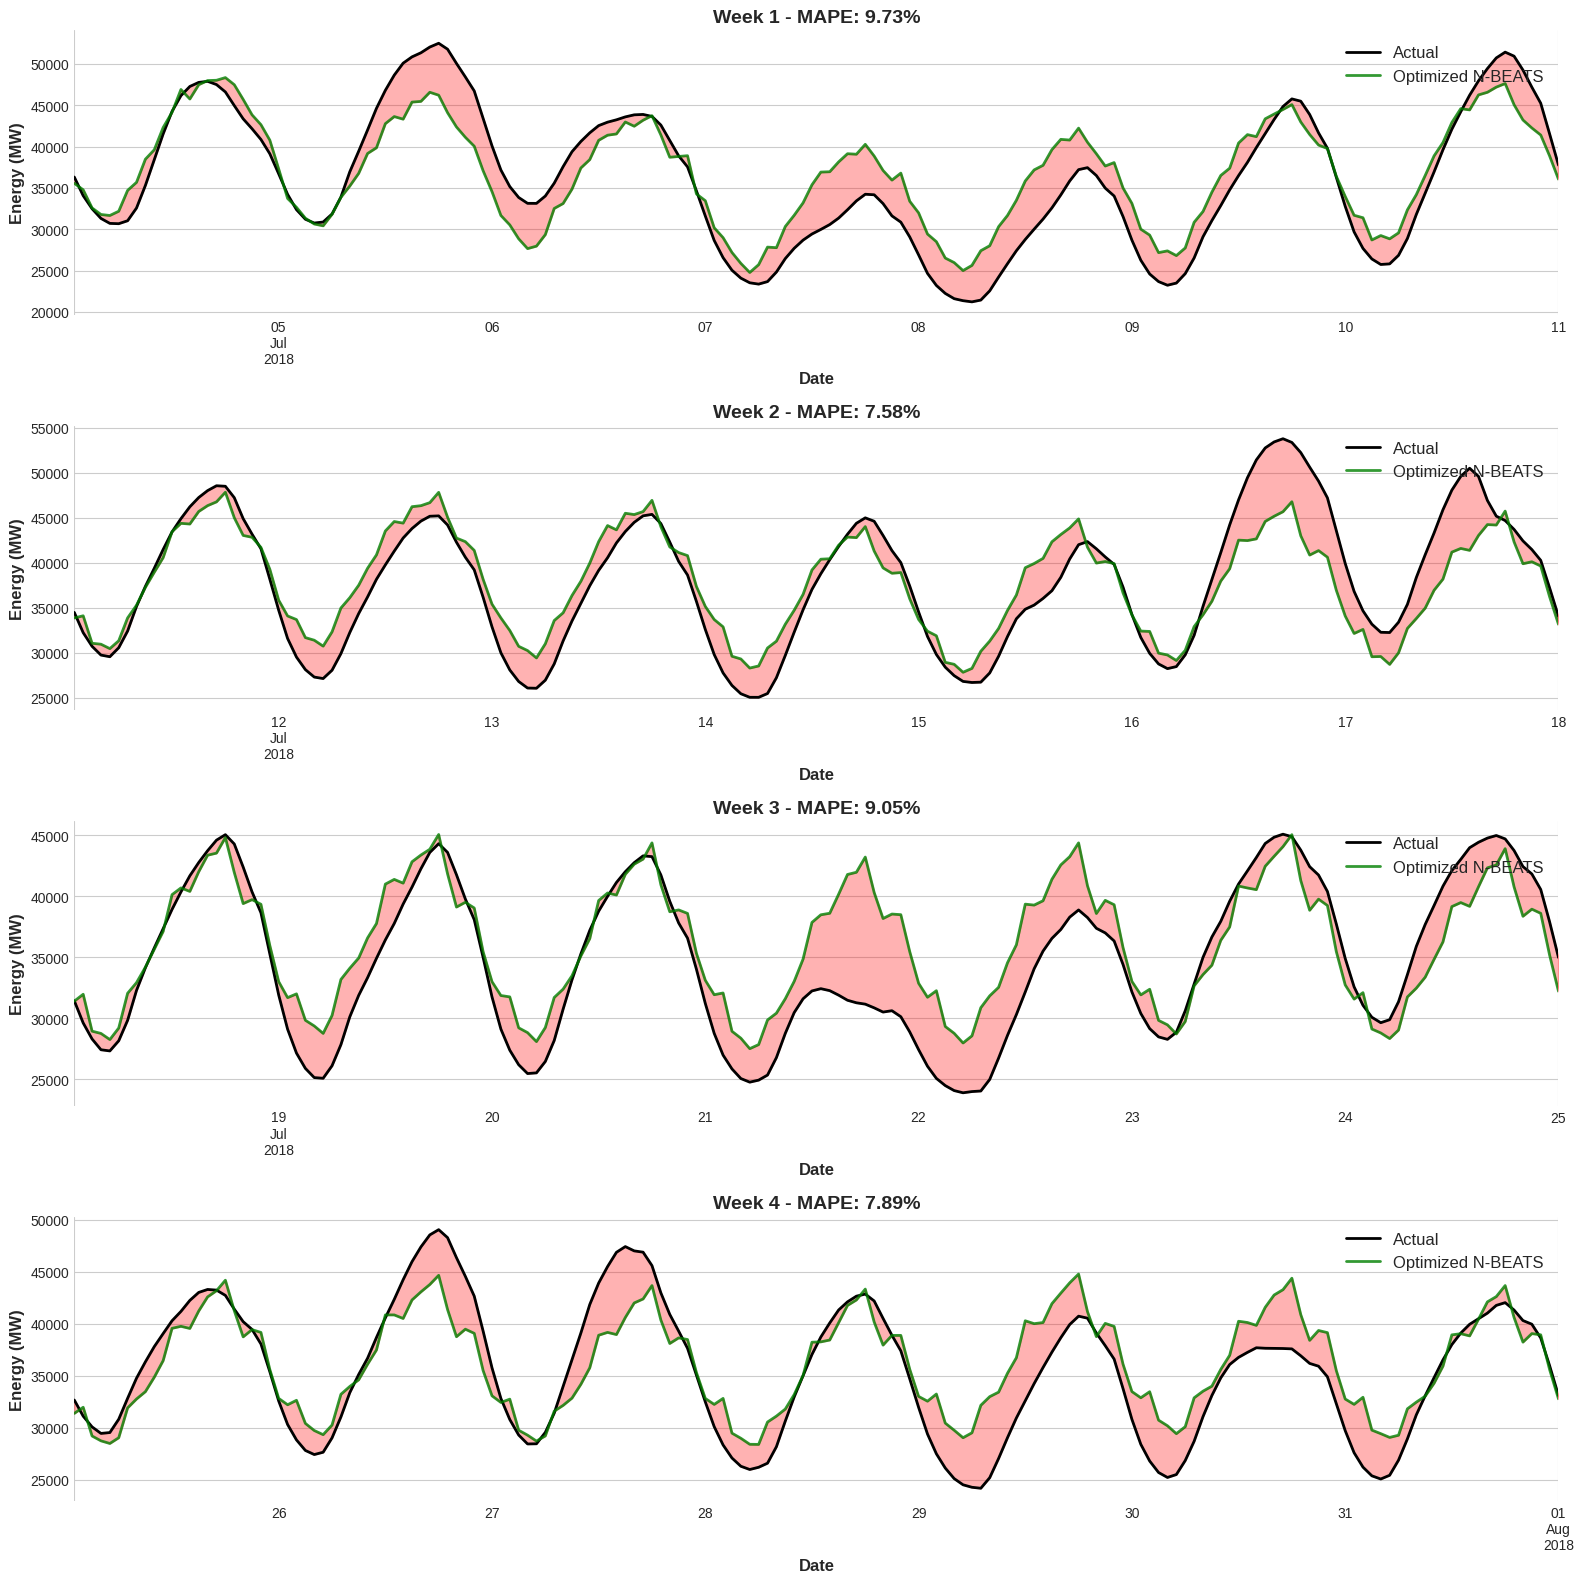


Saved: best_model_weekly.png


In [40]:
# Detailed view: Best model prediction vs actual
best_predictions = model_results[best_model_name]['predictions']

# Plot 1 week at a time
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

weeks = [
    (0, 168, 'Week 1'),
    (168, 336, 'Week 2'),
    (336, 504, 'Week 3'),
    (504, 672, 'Week 4')
]

for idx, (start, end, week_name) in enumerate(weeks):
    ax = axes[idx]

    # Get slices
    actual_week = test[start:end]
    pred_week = best_predictions[start:end]

    actual_week.plot(ax=ax, label='Actual', color='black', linewidth=2)
    pred_week.plot(ax=ax, label=f'{best_model_name}', color='green', linewidth=2, alpha=0.8)

    # Calculate weekly MAPE
    weekly_mape = mape(actual_week, pred_week)

    ax.set_title(f'{week_name} - MAPE: {weekly_mape:.2f}%', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Energy (MW)')
    ax.legend(loc='upper right')
    ax.fill_between(
        actual_week.time_index,
        actual_week.univariate_values().flatten(),
        pred_week.univariate_values().flatten(),
        alpha=0.3,
        color='red'
    )

plt.tight_layout()
plt.savefig('best_model_weekly.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: best_model_weekly.png")


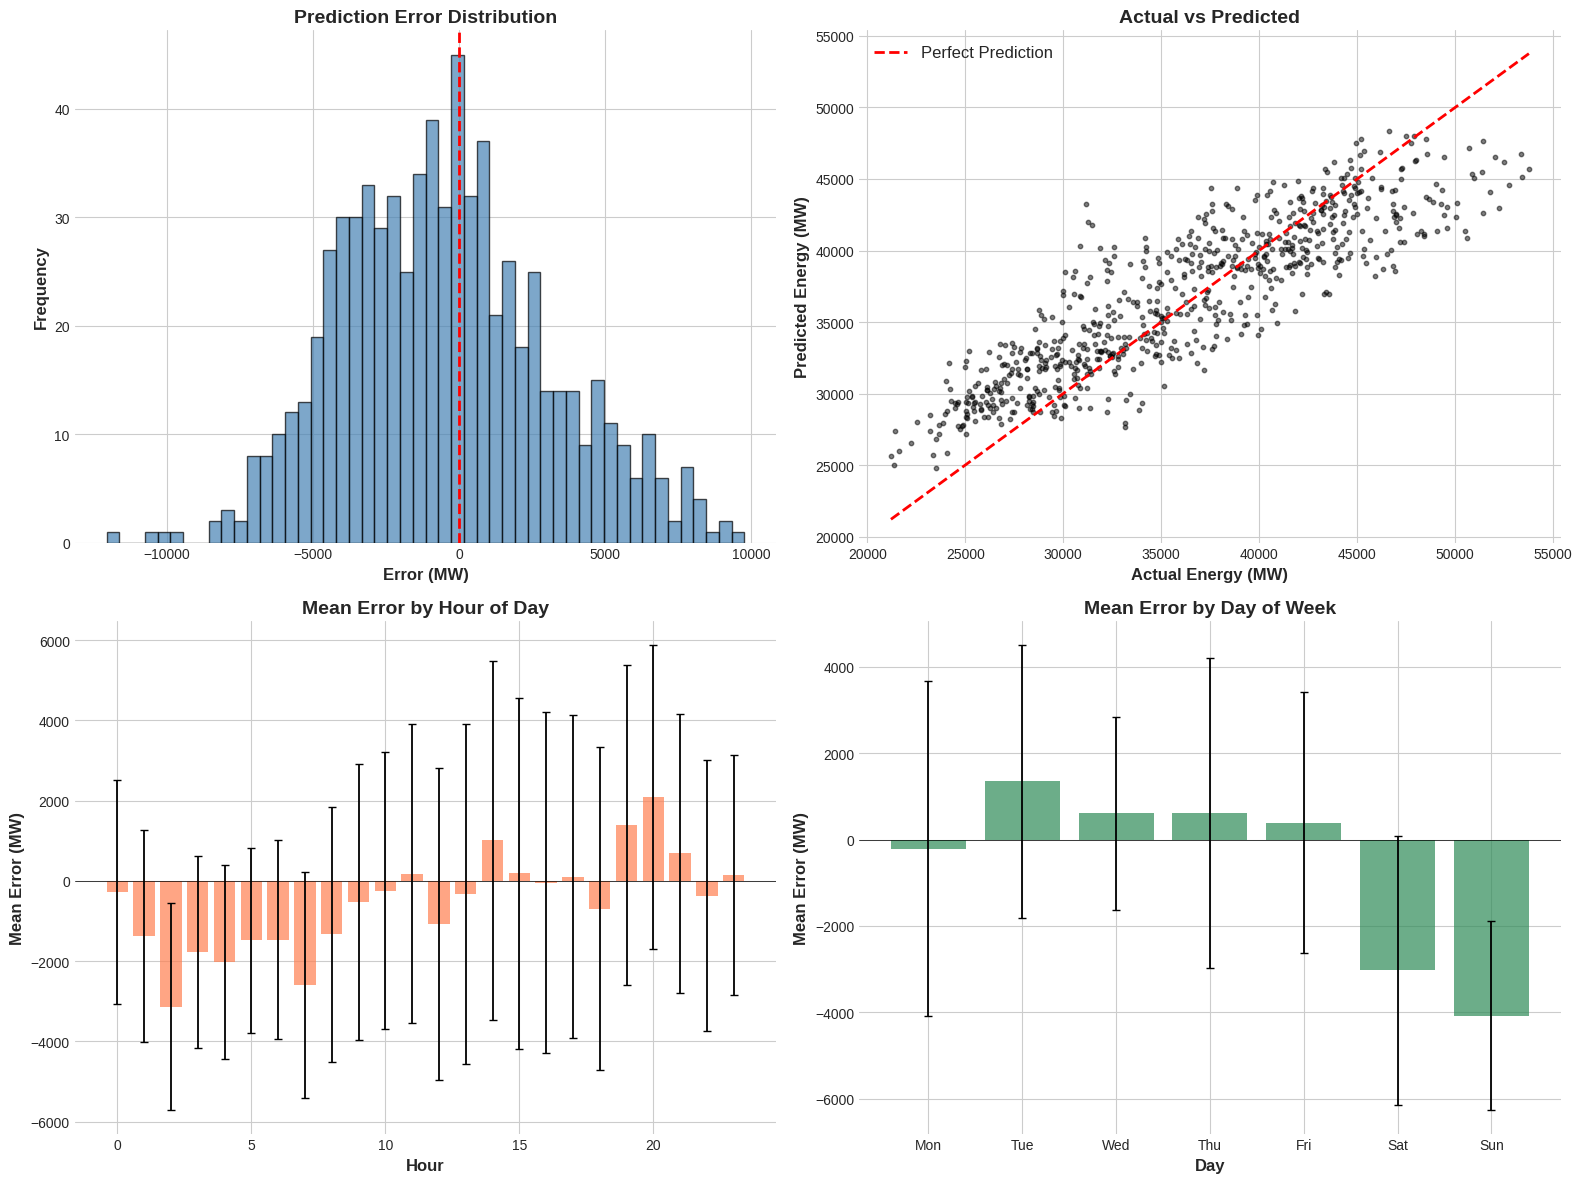


Saved: error_analysis.png


In [41]:
# Error analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get actual and predicted values
actual_values = test.univariate_values().flatten()
pred_values = best_predictions[:len(test)].univariate_values().flatten()
errors = actual_values - pred_values

# Error distribution
axes[0, 0].hist(errors, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Error (MW)')
axes[0, 0].set_ylabel('Frequency')

# Scatter plot: Actual vs Predicted
axes[0, 1].scatter(actual_values, pred_values, alpha=0.5, s=10)
axes[0, 1].plot([actual_values.min(), actual_values.max()],
                [actual_values.min(), actual_values.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Actual Energy (MW)')
axes[0, 1].set_ylabel('Predicted Energy (MW)')
axes[0, 1].legend()

# Error by hour of day
error_by_hour = pd.DataFrame({
    'error': errors,
    'hour': test.time_index.hour
}).groupby('hour')['error'].agg(['mean', 'std'])

axes[1, 0].bar(error_by_hour.index, error_by_hour['mean'],
               yerr=error_by_hour['std'], color='coral', alpha=0.7, capsize=3)
axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].set_title('Mean Error by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Mean Error (MW)')

# Error by day of week
error_by_day = pd.DataFrame({
    'error': errors,
    'day': test.time_index.dayofweek
}).groupby('day')['error'].agg(['mean', 'std'])

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(days, error_by_day['mean'].values,
               yerr=error_by_day['std'].values, color='seagreen', alpha=0.7, capsize=3)
axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].set_title('Mean Error by Day of Week', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Mean Error (MW)')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: error_analysis.png")


In [43]:
# Future forecast (beyond test data)
print("Generating Future Forecast...")

# Train on all available data
full_train_scaled = scaler.fit_transform(series_subset)

# Retrain the best model on full data
future_model = NBEATSModel(
    input_chunk_length=int(best_params.get('input_chunk_length', 168)),
    output_chunk_length=int(best_params.get('output_chunk_length', 24)),
    generic_architecture=True,
    num_stacks=int(best_params.get('num_stacks', 10)),
    num_blocks=1,
    num_layers=int(best_params.get('num_layers', 4)),
    layer_widths=int(best_params.get('layer_widths', 256)),
    n_epochs=200,
    random_state=42,
    batch_size=1024,
    pl_trainer_kwargs={
        "enable_progress_bar": True,
        "accelerator": "auto",
    }
)

future_model.fit(full_train_scaled, verbose=True)

# Predict next 7 days
FUTURE_HORIZON = 24 * 7
future_pred_scaled = future_model.predict(FUTURE_HORIZON)
future_pred = scaler.inverse_transform(future_pred_scaled)

print(f"\nGenerated {FUTURE_HORIZON} hour forecast!")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 202 K  | train
-------------------------------------------------------------
201 K     Trainable params
1.7 K     Non-trainable params
202 K     Total params
0.812     Total estimated m

Generating Future Forecast...


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]


Generated 168 hour forecast!


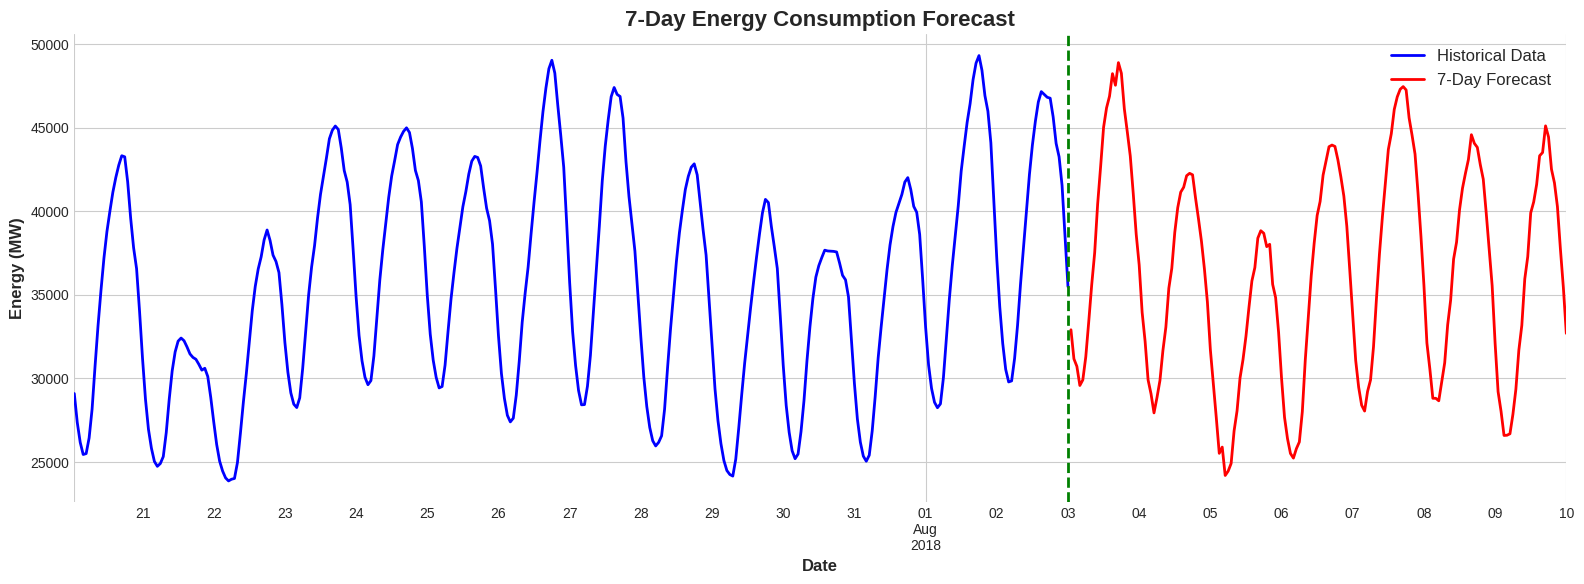


Saved: future_forecast.png


In [44]:
# Plot future forecast
fig, ax = plt.subplots(figsize=(16, 6))

# Plot last 2 weeks of historical data
historical = series_subset[-24*14:]
historical.plot(ax=ax, label='Historical Data', color='blue', linewidth=2)

# Plot future forecast
future_pred.plot(ax=ax, label='7-Day Forecast', color='red', linewidth=2)

ax.set_title('7-Day Energy Consumption Forecast', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MW)')
ax.legend(loc='upper right')
ax.axvline(x=series_subset.end_time(), color='green', linestyle='--', linewidth=2, label='Forecast Start')

plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: future_forecast.png")


---
## Summary

### Key Findings

1. **Seasonality**: The PJME energy data shows strong daily, weekly, and yearly seasonal patterns.

2. **Model Performance**: Deep learning models (N-BEATS, LSTM) generally outperform traditional statistical methods for this dataset.

3. **Best Model**: The optimized N-BEATS model achieved the best performance after hyperparameter tuning.

4. **Feature Importance**: Temporal features (hour of day, day of week) are highly correlated with energy consumption.

### Recommendations

1. For production deployment, consider ensemble methods combining multiple models.
2. Incorporate external features like weather data for improved accuracy.
3. Regularly retrain models as consumption patterns may shift over time.
4. Monitor model performance and implement automated retraining pipelines.


In [45]:
# Save final results
final_df.to_csv('model_results.csv', index=False)
print("Saved: model_results.csv")

# Save best model parameters
import json
with open('best_params.json', 'w') as f:
    json.dump({k: int(v) if isinstance(v, (int, np.integer)) else v for k, v in best_params.items()}, f, indent=2)
print("Saved: best_params.json")

print("\n" + "-"*60)
print("ENERGY FORECASTING PROJECT COMPLETE!")
print("-"*60)


Saved: model_results.csv
Saved: best_params.json

------------------------------------------------------------
ENERGY FORECASTING PROJECT COMPLETE!
------------------------------------------------------------


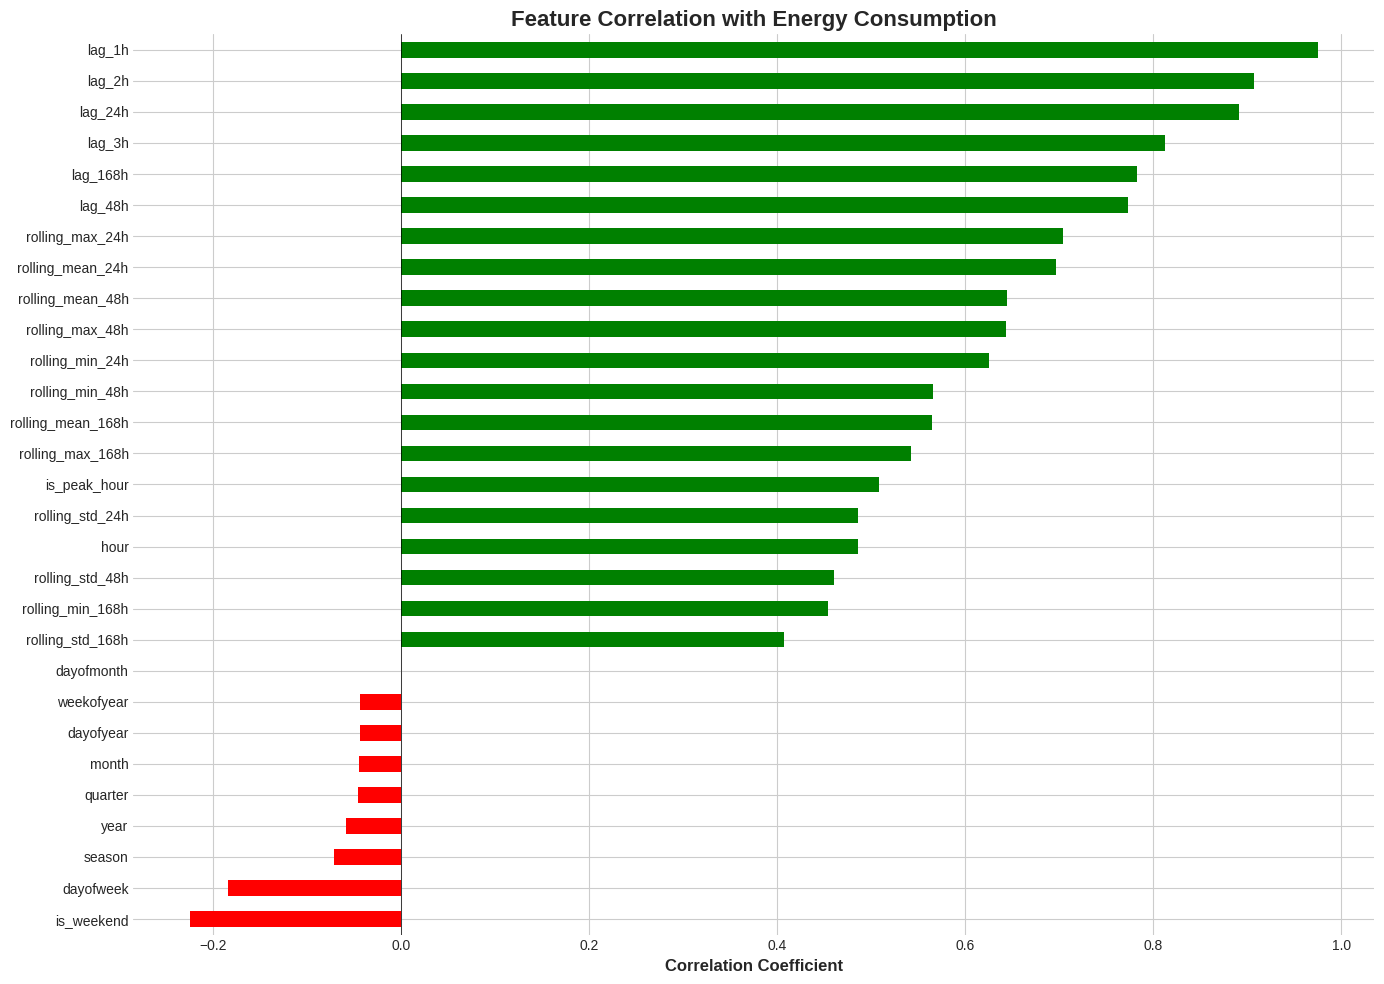

In [46]:
# Feature correlation analysis
fig, ax = plt.subplots(figsize=(14, 10))

# Select numeric columns for correlation
numeric_cols = df_features.select_dtypes(include=[np.number]).columns
corr_matrix = df_features[numeric_cols].dropna().corr()

# Plot correlation with target
target_corr = corr_matrix['energy_consumption'].drop('energy_consumption').sort_values()

colors = ['red' if x < 0 else 'green' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Feature Correlation with Energy Consumption', fontsize=16, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()
